In [1]:
# Загрузите данные и выполните небольшую предобработку

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('/datasets/Kirovskaya_oblast.csv')
# убираем для удобства properties в названии стобцов
df.columns = [c.replace('properties.', '') for c in df.columns]
# приводим названия столбцов в змеиный регистр
df.columns = df.columns.str.replace('.', '_', regex=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry_coordinates    14517 non-null  object 
 1   id                      14517 non-null  int64  
 2   tags                    14517 non-null  object 
 3   light                   14517 non-null  object 
 4   point_lat               14485 non-null  float64
 5   point_long              14485 non-null  float64
 6   nearby                  14517 non-null  object 
 7   region                  14517 non-null  object 
 8   scheme                  13380 non-null  float64
 9   address                 13843 non-null  object 
 10  weather                 14517 non-null  object 
 11  category                14517 non-null  object 
 12  datetime                14517 non-null  object 
 13  injured_count           14517 non-null  int64  
 14  parent_region           14517 non-null

In [2]:
df.head()

,geometry_coordinates,id,tags,light,point_lat,point_long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


In [3]:
df_participiants = pd.read_csv('/datasets/Kirovskaya_oblast_participiants.csv')
df_participiants.head()

,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639



## Исследование данных

### 1. Как распределено количество участников ДТП и почему? Встречаются ли аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Для числа участников найдите наиболее типичное значение. По желанию можете проверить распределения и других столбцов.

РАСПРЕДЕЛЕНИЕ ЧАСТОТ УЧАСТНИКОВ ДТП
1     1533
2     8611
3     2929
4      909
5      353
6      109
7       44
8        9
9        9
10       5
11       2
12       2
14       1
30       1
Name: participants_count, dtype: int64


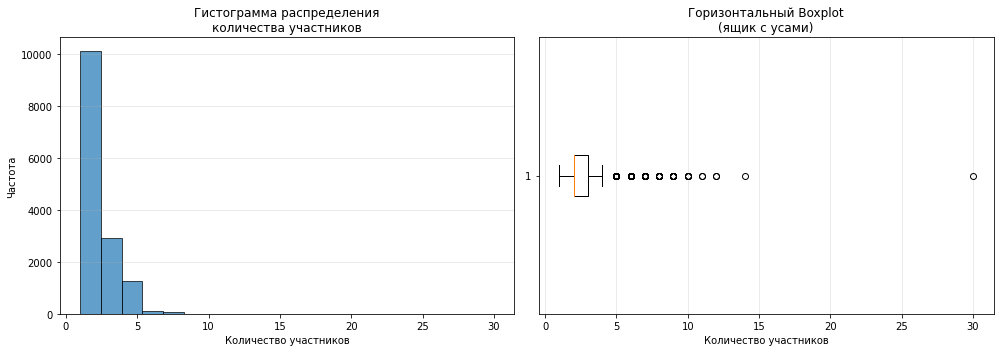

Метод IQR (1.5*IQR):
Q1 = 2.0, Q3 = 3.0, IQR = 1.0
Нижняя граница: 0.5, Верхняя граница: 4.5
Количество выбросов: 535
Выбросы: [5, 6, 7, 8, 9, 10, 11, 12, 14, 30]


In [4]:
# Распределение частот
value_counts = df['participants_count'].value_counts().sort_index()
print(f"РАСПРЕДЕЛЕНИЕ ЧАСТОТ УЧАСТНИКОВ ДТП")
print(value_counts)

# Визуализация 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма
axes[0].hist(df['participants_count'].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Гистограмма распределения\nколичества участников')
axes[0].set_xlabel('Количество участников')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Горизонтальный Boxplot
plt.boxplot(df['participants_count'].dropna(), vert=False)
plt.title('Горизонтальный Boxplot\n(ящик с усами)')
plt.xlabel('Количество участников')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Статистические методы выявления выбросов
# Метод IQR (межквартильный размах)
Q1 = df['participants_count'].quantile(0.25)
Q3 = df['participants_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['participants_count'] < lower_bound) | 
                  (df['participants_count'] > upper_bound)]

print(f"Метод IQR (1.5*IQR):")
print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
print(f"Нижняя граница: {lower_bound}, Верхняя граница: {upper_bound}")
print(f"Количество выбросов: {len(outliers_iqr)}")
print(f"Выбросы: {sorted(outliers_iqr['participants_count'].unique())}")

**Больше всего участников ДТП от 1 до 3, где лидирует 2. Аварий с участниками свыше 5 значительно меньше. Это может быть связано с тем, что наиболее популярный вид транспорта - легковые машины, где максимальное количество людей - 5.\
Есть аномальные значения (5-30), которые могут быть связаны с тем, что в аварии попадают автобусы, где количество пассажиров большое.**

### 2. Предположите,  между какими столбцами в данных высокая корреляция? Проверьте своё предположение.

**Предположения о корреляциях**
1. injured_count (пострадавшие) с participants_count (участники): Чем больше участников, тем вероятнее больше пострадавших

2. injured_count с participant_categories (категории участников): Наличие пешеходов или велосипедистов увеличивает риск травм

3. participants_count с category (категория ДТП): Столкновения обычно вовлекают больше участников, чем наезды

4. weather с road_conditions (погода ↔ состояние покрытия): Плохая погода (дождь, снег) ухудшает состояние дороги

5. light с datetime (освещённость ↔ время): В тёмное время суток освещение хуже

7. nearby (ближайшие объекты) с category: Вблизи пешеходных переходов чаще наезды на пешеходов

In [5]:
# проверяем корреляции
df.corr()

,id,point_lat,point_long,scheme,injured_count,participants_count
id,1.000000,0.044838,0.000309,-0.033493,-0.001796,-0.011355
point_lat,0.044838,1.000000,0.004421,0.022883,-0.029886,-0.000820
point_long,0.000309,0.004421,1.000000,0.021997,-0.005333,-0.008409
scheme,-0.033493,0.022883,0.021997,1.000000,-0.213594,-0.396280
injured_count,-0.001796,-0.029886,-0.005333,-0.213594,1.000000,0.727196
participants_count,-0.011355,-0.000820,-0.008409,-0.396280,0.727196,1.000000


**Обнаруживаем сильную корреляцию между числом пострадавших и числом участников аварии.**

<AxesSubplot:>

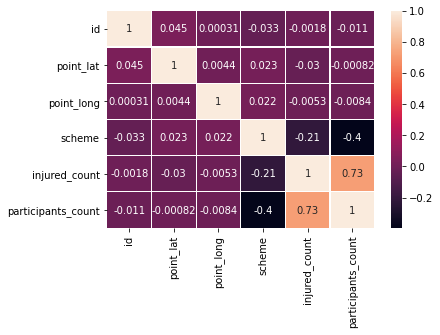

In [6]:
sns.heatmap(df.corr(), linewidth=0.1, annot=True)


Коэффициент корреляции Пирсона: r = 0.7272


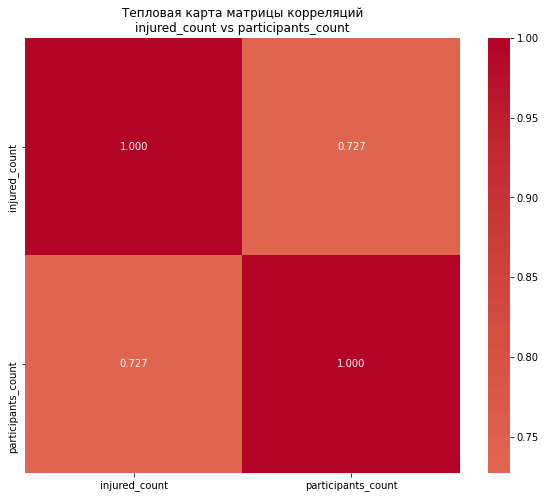

In [7]:
# Проверям 1 предположение: Чем больше участников, тем вероятнее больше пострадавших
# Удалим строки с пропусками для корректного анализа
clean_data = df[['injured_count', 'participants_count']].dropna()

# Коэффициент корреляции Пирсона
corr, p_value = stats.pearsonr(clean_data['participants_count'], clean_data['injured_count'])
print(f"\nКоэффициент корреляции Пирсона: r = {corr:.4f}")

# Визуализация
# Выбираем столбцы для корреляционной матрицы
corr_columns = ['injured_count', 'participants_count']
# Посчитаем матрицу корреляций
corr_matrix = clean_data[corr_columns].corr()
# Создаём тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, square=True)
    
# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций\ninjured_count vs participants_count')
plt.show()

**Корреляция между количеством участников и пострадавших действительно высокая, о чем говорит коэффициент 0,72**

### 3. Как связаны категории аварий и погодные условия?

In [8]:
# Удалим строки с пропусками
clean_data = df[['category', 'weather']].dropna()
# Кросс таблица в относительных частотах
cross_tab = pd.crosstab(clean_data['category'], clean_data['weather'], normalize='index')
cross_tab

weather,"['Дождь', 'Снегопад']","['Дождь', 'Туман']",['Дождь'],['Метель'],"['Пасмурно', 'Дождь']","['Пасмурно', 'Метель']","['Пасмурно', 'Снегопад']","['Пасмурно', 'Температура ниже -30С']","['Пасмурно', 'Туман']","['Пасмурно', 'Ураганный ветер']",['Пасмурно'],"['Снегопад', 'Метель']",['Снегопад'],['Туман'],"['Ясно', 'Температура выше +30С']","['Ясно', 'Температура ниже -30С']","['Ясно', 'Туман']",['Ясно']
category,,,,,,,,,,,,,,,,,,
Иной вид ДТП,0.000000,0.000000,0.015504,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.403101,0.000000,0.023256,0.000000,0.007752,0.000000,0.000000,0.550388
Наезд на велосипедиста,0.000000,0.000000,0.028862,0.000000,0.001698,0.000000,0.000000,0.000000,0.000000,0.000000,0.290323,0.000000,0.001698,0.000000,0.003396,0.000000,0.000000,0.674024
Наезд на внезапно возникшее препятствие,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000
Наезд на животное,0.000000,0.000000,0.044944,0.000000,0.000000,0.000000,0.011236,0.000000,0.000000,0.000000,0.404494,0.000000,0.011236,0.000000,0.000000,0.000000,0.000000,0.528090
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.750000
Наезд на пешехода,0.000458,0.000229,0.050412,0.002062,0.008249,0.000229,0.006187,0.000458,0.000000,0.000000,0.519707,0.000917,0.045830,0.001375,0.003208,0.000458,0.000000,0.360220
Наезд на препятствие,0.000000,0.000000,0.038981,0.000000,0.002999,0.000000,0.005997,0.000000,0.000000,0.000000,0.449775,0.000000,0.035982,0.002999,0.005997,0.001499,0.000000,0.455772


In [9]:
# Кросс таблица в абсолютных частотах
cross_tab_abs = pd.crosstab(clean_data['category'], clean_data['weather'])
cross_tab_abs

weather,"['Дождь', 'Снегопад']","['Дождь', 'Туман']",['Дождь'],['Метель'],"['Пасмурно', 'Дождь']","['Пасмурно', 'Метель']","['Пасмурно', 'Снегопад']","['Пасмурно', 'Температура ниже -30С']","['Пасмурно', 'Туман']","['Пасмурно', 'Ураганный ветер']",['Пасмурно'],"['Снегопад', 'Метель']",['Снегопад'],['Туман'],"['Ясно', 'Температура выше +30С']","['Ясно', 'Температура ниже -30С']","['Ясно', 'Туман']",['Ясно']
category,,,,,,,,,,,,,,,,,,
Иной вид ДТП,0,0,2,0,0,0,0,0,0,0,52,0,3,0,1,0,0,71
Наезд на велосипедиста,0,0,17,0,1,0,0,0,0,0,171,0,1,0,2,0,0,397
Наезд на внезапно возникшее препятствие,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2
Наезд на животное,0,0,4,0,0,0,1,0,0,0,36,0,1,0,0,0,0,47
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",0,0,1,0,0,0,0,0,0,0,7,0,0,0,0,0,0,2
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,9
Наезд на пешехода,2,1,220,9,36,1,27,2,0,0,2268,4,200,6,14,2,0,1572
Наезд на препятствие,0,0,26,0,2,0,4,0,0,0,300,0,24,2,4,1,0,304


In [10]:
# Какая погода чаще всего встречается для каждой категории
most_common_weather = cross_tab_abs.idxmax(axis=1)
print("\nСамая частая погода для каждой категории ДТП:")
for category, weather in most_common_weather.items():
    count = cross_tab_abs.loc[category, weather]
    total = cross_tab_abs.loc[category].sum()
    pct = count / total * 100
    print(f"  {category}: {weather} ({count} ДТП, {pct:.1f}%)")
    
# Какие категории чаще всего встречаются при каждой погоде
most_common_category = cross_tab_abs.idxmax(axis=0)
print("\nСамая частая категория ДТП для каждой погоды:")
for weather, category in most_common_category.items():
    count = cross_tab_abs.loc[category, weather]
    total = cross_tab_abs[weather].sum()
    pct = count / total * 100
    print(f"  {weather}: {category} ({count} ДТП, {pct:.1f}%)")


Самая частая погода для каждой категории ДТП:
  Иной вид ДТП: ['Ясно'] (71 ДТП, 55.0%)
  Наезд на велосипедиста: ['Ясно'] (397 ДТП, 67.4%)
  Наезд на внезапно возникшее препятствие: ['Пасмурно'] (2 ДТП, 50.0%)
  Наезд на животное: ['Ясно'] (47 ДТП, 52.8%)
  Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность: ['Ясно'] (3 ДТП, 100.0%)
  Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы: ['Пасмурно'] (7 ДТП, 70.0%)
  Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ: ['Ясно'] (9 ДТП, 75.0%)
  Наезд на пешехода: ['Пасмурно'] (2268 ДТП, 52.0%)
  Наезд на препятствие: ['Ясно'] (304 ДТП, 45.6%)
  Наезд на стоящее ТС: ['Пасмурно'] (149 ДТП, 47.8%)
  Опрокидывание: ['Ясно'] (532 ДТП, 53.1%)
  Отбрасывание предмета: ['Пасмурно'] (11 ДТП, 61.1%)
  Падение груза: ['Пасмурно'] (1 ДТП, 50.0%)
  Падение пассажира: ['Пасмурно'] (390 ДТП, 52.8%)
  Столкновение: ['П

**Погода влияет на тип ДТП. К примеру, большее число ДТП каждого из видов произошло в пасмурную погоду — это кажется довольно логичным. А разница в числе ДТП с наездом в пасмурные и ясные дни отличается от разницы ДТП со столкновением в тех же погодных условиях. Возможно, при ясной погоде пешеходов замечают лучше, чем другую машину. Причину этой тенденции можно предположить в том, что при столкновении двух машин скорость сближения выше, чем при столкновении пешехода и машины.**

### 4. Постройте процентную разбивку аварий по видам освещённости. При этом учитывайте пол участника и сделайте расчёты для мужчин и женщин отдельно.

In [11]:
# Избавимся от дубликатов
df_participiants = df_participiants.query('role == "Водитель"')
df_participiants = df_participiants.drop_duplicates(subset = 'id')

# Объеденяем датасеты, чтобы узнать пол
merged_df = df.merge(df_participiants[['id', 'gender']], on='id', how='inner')
# Удалим строки с пропусками
clean_data = merged_df[['light', 'gender']].dropna()

# Процентная разбивка 
male_data = clean_data[clean_data['gender'] == 'Мужской']
female_data = clean_data[clean_data['gender'] == 'Женский']

if len(male_data) > 0:
    male_light_dist = male_data['light'].value_counts(normalize=True) * 100
    print("\nМужчины:")
    for light_type, pct in male_light_dist.items():
        count = male_data[male_data['light'] == light_type].shape[0]
        print(f"  {light_type}: {pct:.1f}% ({count} ДТП)")
else:
    print("\nМужчины: данные отсутствуют")
    
if len(female_data) > 0:
    female_light_dist = female_data['light'].value_counts(normalize=True) * 100
    print("\nЖенщины:")
    for light_type, pct in female_light_dist.items():
        count = female_data[female_data['light'] == light_type].shape[0]
        print(f"  {light_type}: {pct:.1f}% ({count} ДТП)")
else:
    print("\nЖенщины: данные отсутствуют")


Мужчины:
  Светлое время суток: 63.7% (6905 ДТП)
  В темное время суток, освещение включено: 21.9% (2372 ДТП)
  В темное время суток, освещение отсутствует: 9.8% (1067 ДТП)
  Сумерки: 3.1% (339 ДТП)
  В темное время суток, освещение не включено: 1.5% (164 ДТП)

Женщины:
  Светлое время суток: 64.2% (1096 ДТП)
  В темное время суток, освещение включено: 22.0% (376 ДТП)
  В темное время суток, освещение отсутствует: 9.8% (168 ДТП)
  Сумерки: 2.8% (48 ДТП)
  В темное время суток, освещение не включено: 1.1% (18 ДТП)


**Для женщин и мужчин аварии по видам освещенности распределены примерно одинаково. При этом для обоих полов характерно наибольшее число аварий в светлое время суток.**

### 5. Исследуйте, чем отличаются аварии без пострадавших от тех, в которых был один пострадавший или более.

In [12]:
# Создаём категорию тяжести ДТП
def severity_category(injured_count):
    if pd.isna(injured_count):
        return 'unknown'
    elif injured_count == 0:
        return 'без пострадавших'
    elif injured_count == 1:
        return '1 пострадавший'
    else:
        return '2+ пострадавших'

df['severity'] = df['injured_count'].apply(severity_category)

# Проверка распределения
print("=== РАСПРЕДЕЛЕНИЕ ДТП ПО ТЯЖЕСТИ ===")
print(df['severity'].value_counts())
print(f"\nПроценты:")
print(df['severity'].value_counts(normalize=True) * 100)

# СРАВНЕНИЕ ПО КОЛИЧЕСТВУ УЧАСТНИКОВ
print("=== СРАВНЕНИЕ ПО КОЛИЧЕСТВУ УЧАСТНИКОВ ===")
participants_stats = df.groupby('severity')['participants_count'].agg(['mean', 'median', 'std', 'count'])
print("\nСтатистика по количеству участников:")
print(participants_stats.round(2))

# СРАВНЕНИЕ ПО КАТЕГОРИИ ДТП
print("=== СРАВНЕНИЕ ПО КАТЕГОРИЯМ ДТП ===")
category_cross = pd.crosstab(df['category'], df['severity'], normalize='index') * 100
# Сортируем
if '2+ пострадавших' in category_cross.columns and '1 пострадавший' in category_cross.columns:
    category_cross_sorted = category_cross.sort_values(['2+ пострадавших', '1 пострадавший'], ascending=[False, False])
elif '2+ пострадавших' in category_cross.columns:
    category_cross_sorted = category_cross.sort_values('2+ пострадавших', ascending=False)
else:
    category_cross_sorted = category_cross.sort_values('1 пострадавший', ascending=False)
print("\nРаспределение категорий ДТП по тяжести (%, отсортировано по опасности):")
print(category_cross_sorted.round(1))

=== РАСПРЕДЕЛЕНИЕ ДТП ПО ТЯЖЕСТИ ===
1 пострадавший     11562
2+ пострадавших     2955
Name: severity, dtype: int64

Проценты:
1 пострадавший     79.644555
2+ пострадавших    20.355445
Name: severity, dtype: float64
=== СРАВНЕНИЕ ПО КОЛИЧЕСТВУ УЧАСТНИКОВ ===

Статистика по количеству участников:
                 mean  median   std  count
severity                                  
1 пострадавший   2.07       2  0.64  11562
2+ пострадавших  3.46       3  1.35   2955
=== СРАВНЕНИЕ ПО КАТЕГОРИЯМ ДТП ===

Распределение категорий ДТП по тяжести (%, отсортировано по опасности):
severity                                            1 пострадавший  \
category                                                             
Наезд на лицо, не являющееся участником дорожно...            33.3   
Столкновение                                                  65.4   
Наезд на животное                                             67.4   
Съезд с дороги                                                72.4   
На

**Нужно взять ДТП, в которых injured_count == 0. Однако таких аварий в данных не оказалось. Но данных есть столбец health_status, и на него можно опираться при оценке пострадавших. Стоит обсудить с заказчиком, почему injured_count не согласуется с health_status.**

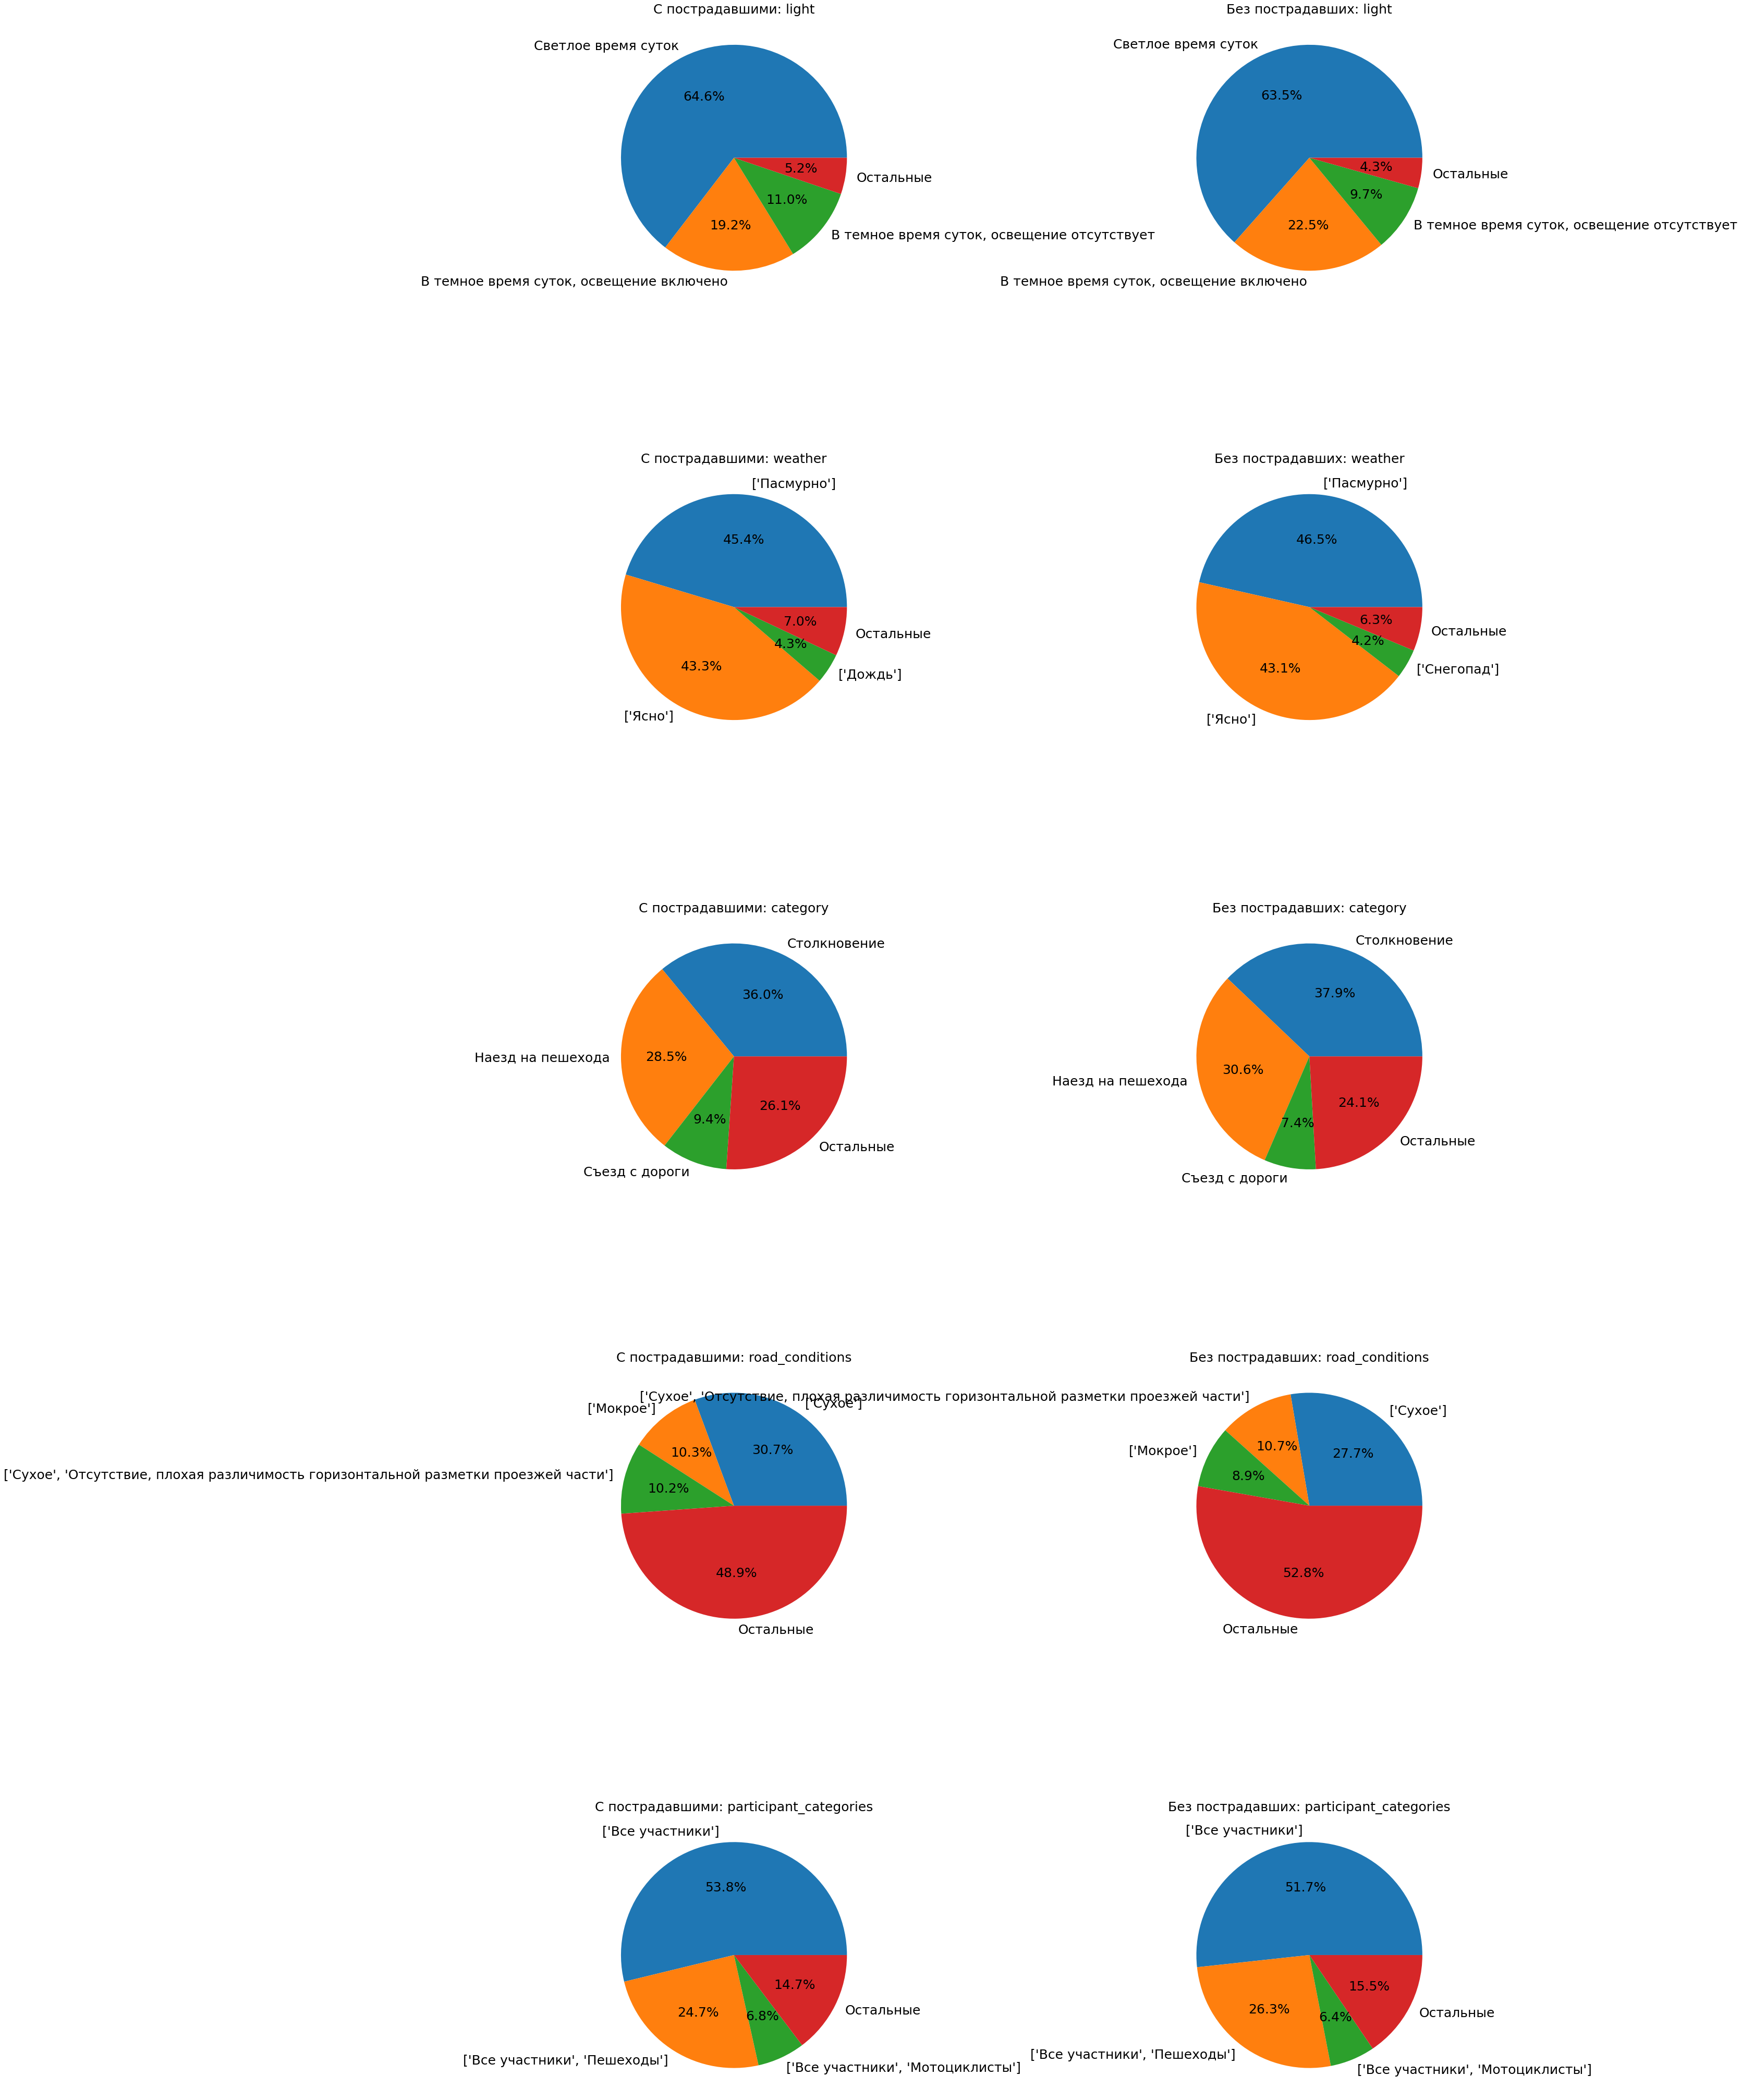

In [30]:
df_res = df_participiants.merge(df, on='id')
ids_injured = df_res.query('health_status != "Не пострадал"')['id'].unique()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(40, 60))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

for i, column_name in enumerate(['light', 'weather', 'category', 'road_conditions', 'participant_categories']):
    # ДТП с пострадавшими
    injured_vals = df.query('id in @ids_injured')[column_name].value_counts(normalize=True)
    # Добавляем категорию "Остальные" если есть
    if len(injured_vals) > 3:
        other_sum = injured_vals.iloc[3:].sum()
        injured_vals = injured_vals.head(3)
        if other_sum > 0:
            injured_vals['Остальные'] = other_sum
    
    # ДТП без пострадавших
    no_injured_vals = df.query('id not in @ids_injured')[column_name].value_counts(normalize=True)
    # Добавляем категорию "Остальные" если есть
    if len(no_injured_vals) > 3:
        other_sum = no_injured_vals.iloc[3:].sum()
        no_injured_vals = no_injured_vals.head(3)
        if other_sum > 0:
            no_injured_vals['Остальные'] = other_sum
    
    # Рисуем круговые диаграммы с normalize=True
    axes[i, 0].pie(injured_vals.values, 
                   labels=injured_vals.index, 
                   autopct='%1.1f%%',
                   normalize=True,
                   textprops={'fontsize': 25}) 
    axes[i, 0].set_title(f'С пострадавшими: {column_name}', fontsize=25)
    
    axes[i, 1].pie(no_injured_vals.values, 
                   labels=no_injured_vals.index, 
                   autopct='%1.1f%%',
                   normalize=True,
                   textprops={'fontsize': 25})  
    axes[i, 1].set_title(f'Без пострадавших: {column_name}', fontsize=25)

plt.tight_layout()
plt.show()

**Рассмотрели несколько признаков, и по ним не видно различий в относительных долях ДТП с пострадавшими и без.**

### 6. Сделайте общий вывод о связи аварийности с другими факторами. Какие рекомендации вы можете дать заказчику?

1. Самые распространённые аварии — столкновение и наезд на пешехода — происходят при пасмурной погоде. Разрыв в числе столкновений при ясной и пасмурной погоде несущественный, однако наезды на пешеходов при ясной погоде происходят реже. Возможно, при столкновении двух машин скорость сближения выше, чем при столкновении пешехода и машины. Стоит также отметить, что съезд с дороги, опрокидывания и наезды на препятствия случались чаще в ясную погоду.

2. В разбивке по полам и освещённости различий не обнаружено. 

3. В данных встречается ДТП с 30 участниками.

4. В датасете число пострадавших в injured_count не согласуется с health_status. Стоит узнать у заказчика, почему так произошло.